# Comparing Local Explanations

We focus on tabular data.
- Local ALE (my contribution)
- LIME
- Ceteris Paribus Plots
- Counterfactuals

We implement all explainers ourselves.
- The Ceteris Paribus plot is self-explanatory, and is also known as an Individual Conditional Expectation (ICE) plot.
- We convert the implementation for LIME, which is originally for classificaiton, to a version for regression. We adapted from the LIME repository: [LIME Python implementation](https://github.com/marcotcr/lime/tree/ce2db6f20f47c3330beb107bb17fd25840ca4606).
- We implement permutation sampling for Shapley values, which is the standard sampling method used in practice.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cp import CeterisParibus
from ale import ALE
from lime import LIME
from shap import SHAP

from utils import bin_selection

In [2]:
# generate data
def generate_2d_data(n, sigma=0.05):
    Z = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    epsilon = np.random.normal(0, sigma, n)
    X1 = Z
    X2 = Z + epsilon

    return np.vstack([X1, X2]).T

def generate_2d_data_normal(n, rho=0.5):
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]  # covariance matrix
    data = np.random.multivariate_normal(mean, cov, n)
    return data

def generate_3d_data(n, sigma=0.05):
    Z = np.random.uniform(1, 2, n)
    epsilon_1 = np.random.normal(0, sigma, n)
    epsilon_2 = np.random.normal(0, sigma, n)
    epsilon_3 = np.random.normal(0, sigma, n)
    X1 = Z + epsilon_1
    X2 = Z + epsilon_2
    X3 = Z + epsilon_3
    return np.vstack([X1, X2, X3]).T

def generate_mixed_data(n, num_categories=3):
    x1 = np.random.randint(0, num_categories, n)
    x2 = np.random.uniform(0, 1, n)
    return np.vstack([x1, x2]).T

In [3]:
f = lambda x: x[:, 0] + x[:, 1] ** 2
n = 200
X = generate_2d_data_normal(n, rho=0.8)
y = f(X)
bins = bin_selection(n)

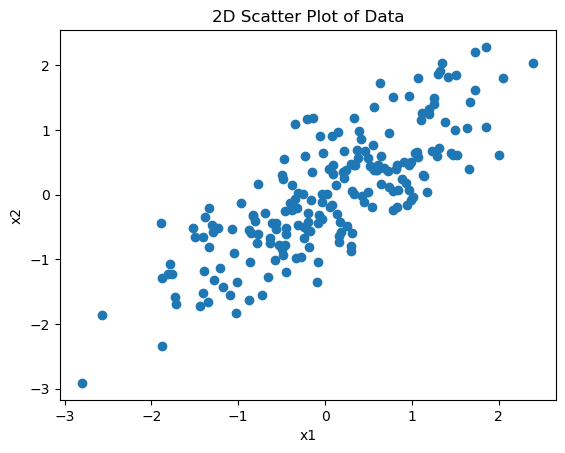

In [4]:
# 2d scatter plot
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Scatter Plot of Data")
plt.show()

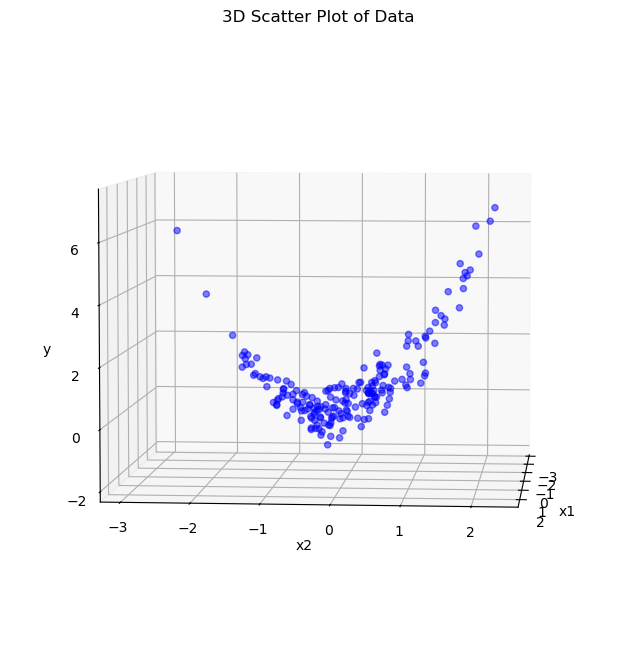

In [5]:
# 3d scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(5, 5)
ax.scatter(X[:, 0], X[:, 1], y, c='blue', marker='o', alpha=0.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('3D Scatter Plot of Data')
plt.show()

Feature | Value
-------------------
X1 | [0.22335482]
X2 | [0.67927608]
-------------------
Prediction: 0.6847708108595251


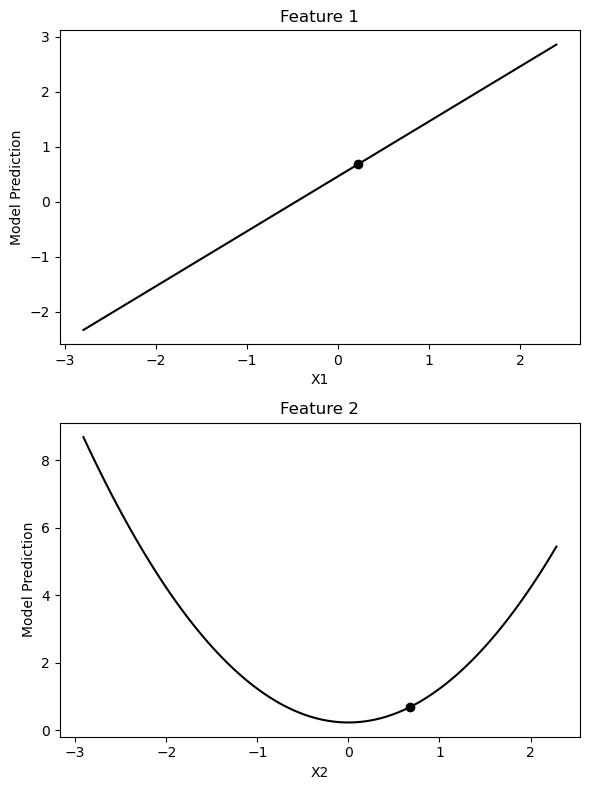

In [6]:
cp = CeterisParibus(f, X, bins=100)
cp.explain_local(0)

In [7]:
def replicate_local_explanations(dgp, f, x_explain, explainer="ale", n=200, m=50):
    bins = bin_selection(n)
    local_explanations = []
    for _ in range(m):
        X = dgp(n)
        X[0, :] = x_explain
        if explainer == "lime":
            explaination = LIME(f, X, verbose=False)
        elif explainer == "ale":
            explaination = ALE(f, X, bins=bins, verbose=False)
            explaination.explain()
        elif explainer == "shap":
            explaination = SHAP(f, X, verbose=False)
        else:
            raise ValueError("Unknown explainer type. Choose from 'ale', 'cp', or 'lime'.")

        local_exp = explaination.explain_local(0)
        # convert dictionary to array
        local_exp_array = np.array([local_exp[feature] for feature in local_exp.keys()])
        local_explanations.append(local_exp_array)
    return np.array(local_explanations)

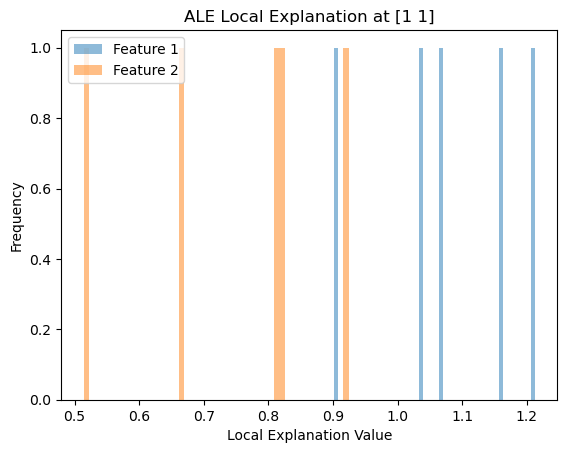

In [8]:
normal_dgp = lambda n: generate_2d_data_normal(n, rho=0.8)
uniform_dgp = lambda n: generate_2d_data(n, sigma=0.05)
x_explain = np.array([1, 1])
derivative_at_x_explain = np.array([1, 2 * x_explain[1]])
replications = replicate_local_explanations(uniform_dgp, f, x_explain, explainer="ale", n=100, m=5)
for i in range(replications.shape[1]):
    plt.hist(replications[:, i], bins=50, alpha=0.5, label=f'Feature {i+1}')
plt.xlabel('Local Explanation Value')
plt.ylabel('Frequency')
plt.title(f'ALE Local Explanation at {x_explain}')
plt.legend()
plt.show()

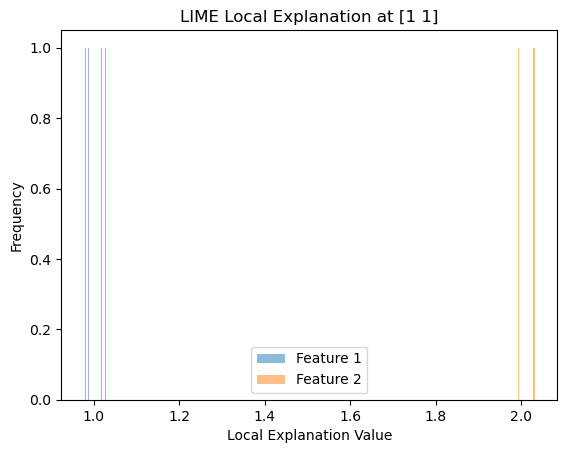

In [9]:
replications = replicate_local_explanations(uniform_dgp, f, x_explain, explainer="lime", n=100, m=5)
for i in range(replications.shape[1]):
    plt.hist(replications[:, i], bins=50, alpha=0.5, label=f'Feature {i+1}')
plt.xlabel('Local Explanation Value')
plt.ylabel('Frequency')
plt.title(f'LIME Local Explanation at {x_explain}')
plt.legend()
plt.show()

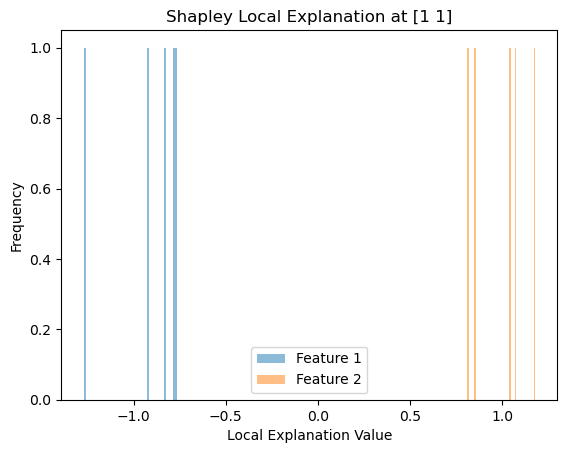

In [10]:
replications = replicate_local_explanations(uniform_dgp, f, x_explain, explainer="shap", n=100, m=5)
for i in range(replications.shape[1]):
    plt.hist(replications[:, i], bins=50, alpha=0.5, label=f'Feature {i+1}')
plt.xlabel('Local Explanation Value')
plt.ylabel('Frequency')
plt.title(f'Shapley Local Explanation at {x_explain}')
plt.legend()
plt.show()